# plot_existing_data
Interactive replay of saved telemetry CSVs.

**Usage:**
1. Set `CSI_FILE` and/or `CBF_FILE` to point at your CSV files.
2. Run all cells.
3. Use the **Time** slider to replay data over time.
4. Use plot-type buttons to open each specific plot.

In [1]:
import sys, os
# Ensure this directory is on the path
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import yaml
from IPython.display import display
from collections import deque
import threading

import dsp
import rare_est
import special_plots as sp
from plot_types.waterfalls import WaterfallFigure
from plot_types.complex_plane import ComplexPlaneFigure
from plot_types.time_series import TimeSeriesFigure
from plot_types.histograms import HistogramFigure

%matplotlib widget

In [2]:
# ------- CONFIGURE FILE PATHS HERE -------
CSI_FILE = ''   # e.g. '../../database/collected_data/20260630_120000_CSI_INFO.csv'
CBF_FILE = '../../database/collected_data/20260701_202506_CBF_INFO.csv'   # e.g. '../../database/collected_data/20260630_120000_CBF_INFO.csv'
# -----------------------------------------

ARRAY_SHAPE = (2, 2)   # (rows, cols) for rectangular UPA geometry
# WINDOW / SMOOTH / ANTIALIAS / DENOM_LIM are loaded from config.yaml above

In [3]:
# ------- CONFIGURE FILE PATHS HERE -------
CSI_FILE = ''   # e.g. '../../database/collected_data/20260630_120000_CSI_INFO.csv'
CBF_FILE ='../../database/collected_data/20260701_202506_CBF_INFO.csv'     # e.g. '../../database/collected_data/20260630_120000_CBF_INFO.csv'
# -----------------------------------------

ARRAY_SHAPE = (2, 2)   # (rows, cols) for rectangular UPA geometry
WINDOW      = 200      # sliding window depth

In [4]:
# ---- Load CSI CSV ----
csi_by_mac = {}   # mac -> list of {amp, phase, rssi, channel}
csi_order  = []

if CSI_FILE:
    df_csi = pd.read_csv(CSI_FILE)
    amp_cols   = [c for c in df_csi.columns if c.startswith('amp_')]
    phase_cols = [c for c in df_csi.columns if c.startswith('phase_')]
    for mac, grp in df_csi.groupby('src_mac'):
        grp = grp.sort_values('frame_idx')
        csi_order.append(mac)
        csi_by_mac[mac] = [
            {'amp':   row[amp_cols].values.astype(float),
             'phase': row[phase_cols].values.astype(float),
             'rssi':  int(row['rssi']),
             'channel': int(row['channel'])}
            for _, row in grp.iterrows()
        ]
    print(f'CSI: {len(csi_order)} MAC(s), '
          f'{sum(len(v) for v in csi_by_mac.values())} frames')
else:
    print('No CSI file specified.')

No CSI file specified.


In [5]:
# ---- Load CBF CSV ----
cbf_by_mac   = {}   # mac -> list of v_all (n_sc, nr, nc) frames
cbf_meta     = {}   # mac -> {nr, nc, snr}
cbf_order    = []

def _reconstruct_v(frame_grp, nr, nc, n_sc):
    v_all = np.zeros((n_sc, nr, nc), dtype=complex)
    for r in range(nr):
        for c in range(nc):
            ac = f'amp_rx{r}_stream{c}'
            pc = f'phase_rx{r}_stream{c}'
            if ac not in frame_grp.columns:
                continue
            amp   = frame_grp[ac].values.astype(float)
            phase = frame_grp[pc].values.astype(float)
            amp[np.isnan(amp)]     = 0.0
            phase[np.isnan(phase)] = 0.0
            for k in range(min(n_sc, len(amp))):
                v_all[k, r, c] = amp[k] * np.exp(1j * phase[k])
    return v_all

if CBF_FILE:
    df_cbf = pd.read_csv(CBF_FILE)
    for mac, mac_grp in df_cbf.groupby('mac'):
        cbf_order.append(mac)
        nr = int(mac_grp['nr'].iloc[0])
        nc = int(mac_grp['nc'].iloc[0])
        snr_cols = sorted(c for c in mac_grp.columns if c.startswith('snr_stream'))
        snr = [int(mac_grp[c].iloc[-1]) for c in snr_cols]
        cbf_meta[mac] = {'nr': nr, 'nc': nc, 'snr': snr}

        frames = []
        for fidx, fg in mac_grp.groupby('frame_idx'):
            fg    = fg.sort_values('sc_idx')
            n_sc  = len(fg)
            v_all = _reconstruct_v(fg, nr, nc, n_sc)
            frames.append(v_all)
        cbf_by_mac[mac] = frames

    print(f'CBF: {len(cbf_order)} MAC(s), '
          f'{sum(len(v) for v in cbf_by_mac.values())} frames')
else:
    print('No CBF file specified.')

CBF: 2 MAC(s), 114 frames


In [6]:
# ---- Static DataStore (compatible with special_plots API) ----

class StaticStore:
    """Read-only store backed by loaded CSV data.
    
    Exposes the same interface as rx_data.DataStore so special_plots
    functions work without modification.
    
    A `time_idx` property controls which prefix of the frame list
    is visible, simulating replay over time.
    """

    def __init__(self, cbf_by_mac, cbf_meta, cbf_order,
                 csi_by_mac, csi_order, window=WINDOW):
        self.lock       = threading.Lock()
        self._cbf       = cbf_by_mac
        self._cbf_meta  = cbf_meta
        self._cbf_order = cbf_order
        self._csi       = csi_by_mac
        self._csi_order = csi_order
        self._window    = window
        self.time_idx   = max(
            (len(v) for v in cbf_by_mac.values()), default=1)

    @property
    def cbf_order(self):
        return self._cbf_order

    @property
    def cbf_meta(self):
        return self._cbf_meta

    @property
    def cbf_frames(self):
        # Return a dict of deque-like objects windowed by time_idx
        result = {}
        for mac, frames in self._cbf.items():
            end   = min(self.time_idx, len(frames))
            start = max(0, end - self._window)
            slc   = frames[start:end]
            result[mac] = [
                {'v_all': v, 'n_sc': v.shape[0],
                 'nr': v.shape[1], 'nc': v.shape[2]}
                for v in slc
            ]
        return result

    def add_listener(self, fn):
        pass   # no-op for static store

    def stop(self):
        pass


store = StaticStore(
    cbf_by_mac, cbf_meta, cbf_order,
    csi_by_mac, csi_order)

max_frames = max(
    (len(v) for v in cbf_by_mac.values()), default=1)
print(f'Static store ready.  max_frames={max_frames}')

Static store ready.  max_frames=65


In [ ]:
# ---- VVH Waterfall ----
# Uncomment to open:
# fig_vvh_wf, ani_vvh_wf = sp.VVH_waterfall(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS)
# plt.show()

In [ ]:
# ---- VVH Complex Plane ----
# fig_vvh_cpx, ani_vvh_cpx = sp.VVH_cplx(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS)
# plt.show()

In [ ]:
# ---- VVH SS Waterfall ----
# fig_ss_wf, ani_ss_wf = sp.VVH_ss_waterfall(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS)
# plt.show()

In [ ]:
# ---- VVH SS Complex Plane ----
# fig_ss_cpx, ani_ss_cpx = sp.VVH_ss_cplx(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS)
# plt.show()

In [ ]:
# ---- VVH Ratio Waterfall ----
# fig_ratio_wf, ani_ratio_wf = sp.VVH_ratio_waterfall(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS, denom_lim=DENOM_LIM)
# plt.show()

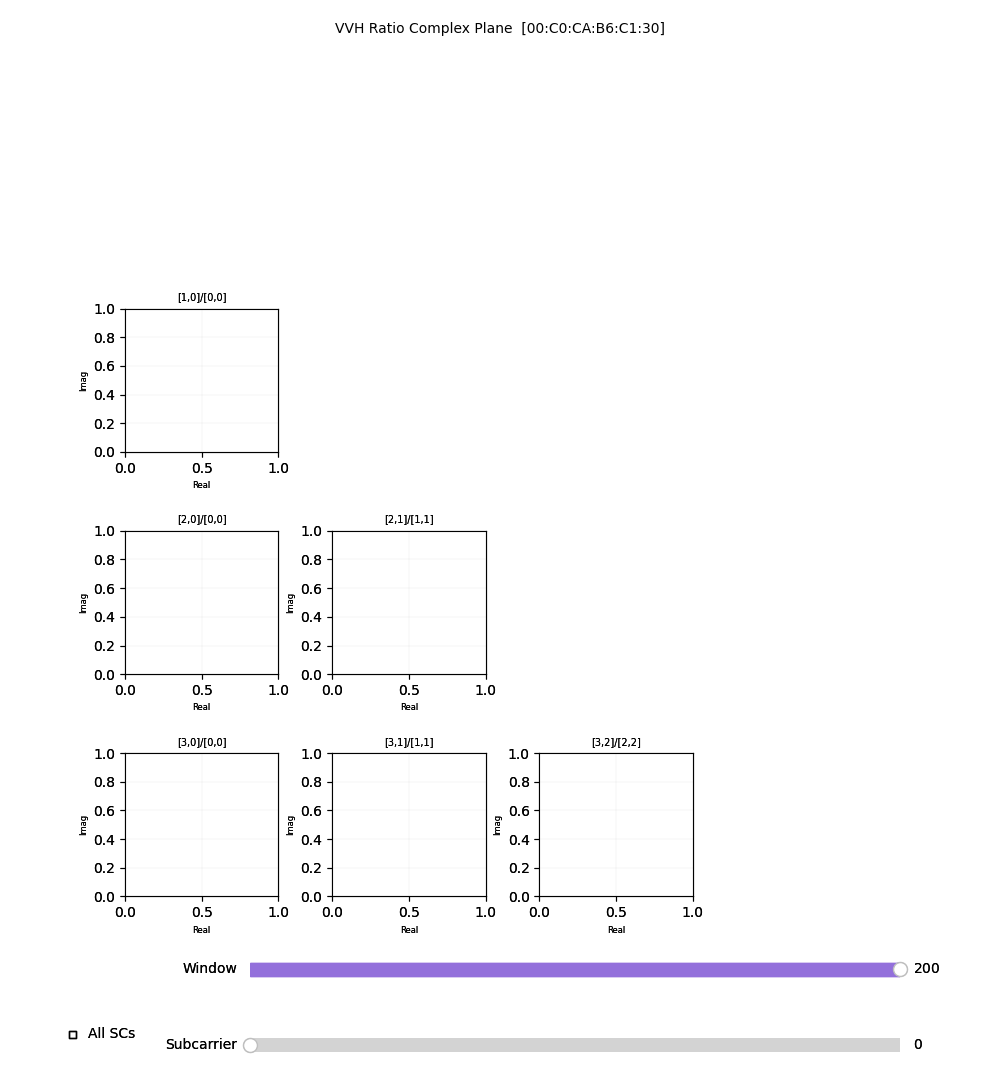

In [16]:
# ---- VVH Ratio Complex Plane ----
SMOOTH=False
ANTIALIAS=True
DENOM_LIM=0.01
fig_ratio_cpx, ani_ratio_cpx = sp.VVH_ratio_cplx(
    store, interval=300, window=WINDOW,
    denoise=SMOOTH, antialias=ANTIALIAS, denom_lim=DENOM_LIM)
plt.show()

In [ ]:
# ---- VVH Ratio SS Waterfall ----
# fig_ratio_ss_wf, ani_ratio_ss_wf = sp.VVH_ratio_ss_waterfall(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS, denom_lim=DENOM_LIM)
# plt.show()

In [ ]:
# ---- VVH Ratio SS Complex Plane ----
# fig_ratio_ss_cpx, ani_ratio_ss_cpx = sp.VVH_ratio_ss_cplx(
#     store, interval=300, window=WINDOW,
#     denoise=SMOOTH, antialias=ANTIALIAS, denom_lim=DENOM_LIM)
# plt.show()

In [ ]:
# ---- Estimated Array + AoA ----
# fig_array, ani_array = sp.est_array_plot(
#     store, interval=300, window=WINDOW)
# plt.show()

In [ ]:
# ---- Open all plots at once ----

def open_all_plots():
    """Open every specific plot type simultaneously."""
    fns = [
        sp.VVH_waterfall,
        sp.VVH_cplx,
        sp.VVH_ss_waterfall,
        sp.VVH_ss_cplx,
        sp.VVH_ratio_waterfall,
        sp.VVH_ratio_cplx,
        sp.VVH_ratio_ss_waterfall,
        sp.VVH_ratio_ss_cplx,
        sp.est_array_plot,
    ]
    _kw = dict(
        interval=300,
        window=WINDOW,
        denoise=SMOOTH,
        antialias=ANTIALIAS,
        denom_lim=DENOM_LIM,
    )
    figs, anis = [], []
    for fn in fns:
        try:
            f, a = fn(store, **_kw)
            figs.append(f)
            anis.append(a)
        except Exception as e:
            print(f'{fn.__name__}: {e}')
    plt.show()
    return figs, anis

# Uncomment to open all:
# figs, anis = open_all_plots()

In [11]:
# ---- Open all plots at once ----

def open_all_plots():
    """Open every specific plot type simultaneously."""
    fns = [
        sp.VVH_waterfall,
        sp.VVH_cplx,
        sp.VVH_ss_waterfall,
        sp.VVH_ss_cplx,
        sp.VVH_ratio_waterfall,
        sp.VVH_ratio_cplx,
        sp.VVH_ratio_ss_waterfall,
        sp.VVH_ratio_ss_cplx,
        sp.est_array_plot,
    ]
    figs, anis = [], []
    for fn in fns:
        try:
            f, a = fn(store, interval=300)
            figs.append(f)
            anis.append(a)
        except Exception as e:
            print(f'{fn.__name__}: {e}')
    plt.show()
    return figs, anis

# Uncomment to open all:
#figs, anis = open_all_plots()